# Projekt: Automatyczne wykrywanie naczyń dna siatkówki oka
### Skład grupy: 

## Wprowadzenie i Opis Projektu
Celem projektu jest stworzenie aplikacji segmentującej naczynia krwionośne na zdjęciach dna siatkówki oka (klasyfikacja binarna: naczynie vs tło).
W projekcie zrealizowano i porównano trzy podejścia:
1. **Podejście klasyczne:** Przetwarzanie obrazów z użyciem wieloskalowego filtru Frangiego.
2. **Uczenie maszynowe:** Klasyfikator Lasu Decyzyjnego (Random Forest) trenowany na cechach statystycznych ekstrahowanych z lokalnych wycinków obrazu o rozmiarze 5x5 pikseli.
3. **Głębokie uczenie:** Głęboka splotowa sieć neuronowa o architekturze U-Net, trenowana w trybie end-to-end bezpośrednio na całych obrazach siatkówki.

Użyta baza danych została załadowana z lokalnego katalogu strukturalnego `data/`.

In [62]:
# Inicjalizacja kontenera środowiskowego
# py install 3.11
# py -3.11 -m venv .venv
# .\.venv\Scripts\activate
# py -m pip install ipykernel numpy opencv-python matplotlib scikit-image scikit-learn tensorflow

In [63]:
import os
import glob
import cv2
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import tensorflow.keras.backend as K
from tensorflow.keras import layers, models
from skimage.filters import frangi
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix

## Ładowanie danych z bazy (Struktura folderów)
Program przeczesuje katalogi `data/images` w poszukiwaniu oryginalnych zdjęć oraz `data/manual1` w poszukiwaniu odpowiadających im masek eksperckich.
Dodatkowo obrazy są automatycznie skalowane (proporcjonalnie do szerokości 600px) w celu optymalizacji zużycia pamięci RAM podczas ekstrakcji cech wycinków.

In [64]:
def load_project_data(base_dir="data", target_width=600):
    images = []
    masks = []
    names = []
    
    img_dir = os.path.join(base_dir, "images")
    manual_dir = os.path.join(base_dir, "manual1")
    
    extensions = ["*.jpg", "*.tif", "*.ppm"]
    img_paths = []
    for ext in extensions:
        img_paths.extend(glob.glob(os.path.join(img_dir, ext)))
    img_paths = sorted(img_paths)
    
    if len(img_paths) == 0:
        raise FileNotFoundError(f"Nie znaleziono obrazów w '{img_dir}'. Sprawdź strukturę folderów.")
        
    for img_path in img_paths:
        base_name = os.path.splitext(os.path.basename(img_path))[0]
        
        mask_match = None
        for ext in extensions:
            potential_path = glob.glob(os.path.join(manual_dir, f"{base_name}{ext.replace('*','')[:4]}*"))
            if potential_path:
                mask_match = potential_path[0]
                break
                
        if mask_match and os.path.exists(mask_match):
            img = cv2.imread(img_path)
            mask = cv2.imread(mask_match, cv2.IMREAD_GRAYSCALE)
            
            h, w, _ = img.shape
            aspect = h / w
            target_height = int(target_width * aspect)
            
            img_res = cv2.resize(img, (target_width, target_height), interpolation=cv2.INTER_LINEAR) # type: ignore
            mask_res = cv2.resize(mask, (target_width, target_height), interpolation=cv2.INTER_NEAREST) # type: ignore
            
            _, mask_bin = cv2.threshold(mask_res, 127, 1, cv2.THRESH_BINARY)
            
            images.append(img_res)
            masks.append(mask_bin)
            names.append(base_name)
        else:
            print(f"Pominięto {base_name} - brak dopasowanej maski w 'manual1'.")
            
    return images, masks, names

images, expert_masks, image_names = load_project_data("data")
print(f"Załadowano pomyślnie {len(images)} obrazów do analizy.")

Załadowano pomyślnie 65 obrazów do analizy.


## Metoda 1: Klasyczne Przetwarzanie Obrazów (Baseline)

#### Przygotowanie danych i poszczególne kroki przetwarzania obrazu
W podejściu klasycznym przetwarzanie opiera się w całości na sekwencyjnym aplikowaniu filtrów cyfrowych na obrazie wejściowym w celu maksymalnego uwypuklenia krawędzi obiektów liniowych. Proces ten składa się z trzech głównych etapów:
1. **Wstępne przetworzenie obrazu (Preprocessing):** * Z wejściowego obrazu RGB wyodrębniany jest kanał zielony (G), cechujący się najlepszym współczynnikiem sygnału do szumu dla struktur naczyniowych.
   * W celu wyrównania lokalnego kontrastu i rozjaśnienia zbyt ciemnych obszarów stosowana jest metoda CLAHE (Contrast Limited Adaptive Histogram Equalization) z parametrem `clipLimit=2.0`.
   * Szum wysokoczęstotliwościowy jest redukowany przy użyciu rozmycia Gaussa (`GaussianBlur`) o rozmiarze jądra $3 \times 3$.
2. **Właściwe przetworzenie obrazu (Core Processing):**
   * Wykorzystywany jest wieloskalowy filtr Frangiego (`frangi` z biblioteki *scikit-image*). Filtr ten analizuje lokalną macierz Hessa dla każdego piksela w zadanych skalach (parametr `sigmas=np.arange(1, 4, 1)`). Pozwala to na wyznaczenie prawdopodobieństwa, czy dany punkt należy do struktury rurkowatej/liniowej.
3. **Końcowe przetwarzanie obrazu (Postprocessing):**
   * Uzyskana z filtra Frangiego ciągła mapa jasności jest normalizowana do pełnego zakresu dynamicznego $0-255$.
   * Następnie przeprowadzana jest automatyczna binaryzacja za pomocą progowania metodą Otsu (`threshold_otsu`), która adaptacyjnie wyznacza punkt odcięcia między naczyniem (klasa pozytywna) a tłem (klasa negatywna), generując wynikową maskę binarną.

In [65]:
def pipeline_image_processing(img_rgb):
    # a) Wstępne przetwarzanie
    green = img_rgb[:, :, 1]
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    enhanced = clahe.apply(green)
    blurred = cv2.GaussianBlur(enhanced, (3, 3), 0)
    
    # b) Właściwe przetwarzanie (Filtr Frangiego)
    vessels_filtered = frangi(blurred, sigmas=np.arange(1, 4, 1), black_ridges=True) # type: ignore
    
    # c) Końcowe przetwarzanie (Progowanie binarne)
    vessels_norm = cv2.normalize(vessels_filtered, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8) # type: ignore
    _, binary_mask = cv2.threshold(vessels_norm, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    
    return (binary_mask // 255).astype(np.uint8)


#### Krótkie uzasadnienie zastosowanego rozwiązania
Wybór kanału zielonego jest standardem w analizie funduskopowej, ponieważ hemoglobina silnie pochłania światło zielone, sprawiając, że naczynia są naturalnie ciemniejsze od otaczającej je tkanki. Filtr Frangiego idealnie nadaje się do tego zadania jako baseline, ponieważ matematycznie reaguje na tzw. „wesselność” (vesselness) – bada drugie pochodne kierunkowe obrazu i wykrywa grzbiety sygnału o przekroju parabolicznym, ignorując jednocześnie izolowane szumy czy duże, jednolite obszary jasne.



## Metoda 2: Uczenie Maszynowe

#### Przygotowanie danych i ekstrakcja cech
W tym podejściu problem segmentacji został sformułowany jako klasyczny algorytm klasyfikacji pikselowej na podstawie lokalnego kontekstu przestrzennego.
1. **Wyznaczanie wycinków (Patches):** Po wstępnym przygotowaniu obrazu (kanał zielony + CLAHE), wokół każdego analizowanego piksela wycinane jest kwadratowe okno (wycinek) o rozmiarze $5 \times 5$ pikseli.
2. **Ekstrakcja cech (Feature Extraction):** Dla każdego wycinka tworzony jest wektor cech opisujący strukturę otoczenia środkowego piksela. Ekstrahowane są następujące cechy statystyczne:
   * Średnia jasność pikseli w oknie,
   * Wariancja jasności (miara lokalnego zróżnicowania/kontrastu),
   * Minimalna wartość jasności w wycinku,
   * Maksymalna wartość jasności w wycinku,
   * Wartość jasności dokładnie centralnego piksela.
Informacja o przynależności do klasy (etykieta) jest pobierana bezpośrednio z maski eksperckiej (Ground Truth) dla piksela znajdującego się w samym środku wycinka.

In [66]:
def extract_features_from_image(img_rgb, expert_mask, samples_per_image=4000):
    green = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8)).apply(img_rgb[:, :, 1])
    h, w = green.shape
    patch_size = 5
    half = patch_size // 2
    
    v_y, v_x = np.where(expert_mask[half:h-half, half:w-half] == 1)
    v_y += half; v_x += half
    
    b_y, b_x = np.where(expert_mask[half:h-half, half:w-half] == 0)
    b_y += half; b_x += half
    
    # Undersampling
    n_samples = min(samples_per_image // 2, len(v_y), len(b_y))
    idx_v = np.random.choice(len(v_y), n_samples, replace=False)
    idx_b = np.random.choice(len(b_y), n_samples, replace=False)
    
    sel_y = np.concatenate([v_y[idx_v], b_y[idx_b]])
    sel_x = np.concatenate([v_x[idx_v], b_x[idx_b]])
    labels = np.concatenate([np.ones(n_samples), np.zeros(n_samples)])
    
    features = []
    for y, x in zip(sel_y, sel_x):
        patch = green[y-half : y+half+1, x-half : x+half+1]
        feats = [np.mean(patch), np.var(patch), np.min(patch), np.max(patch), patch[half, half]]
        features.append(feats)
        
    return np.array(features), labels

def predict_ml_full_image(img_rgb, model):
    green = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8)).apply(img_rgb[:, :, 1])
    h, w = green.shape
    patch_size = 5
    half = patch_size // 2
    
    pred_mask = np.zeros((h, w), dtype=np.uint8)
    features_img = []
    coords = []
    
    for y in range(half, h - half):
        for x in range(half, w - half):
            patch = green[y-half : y+half+1, x-half : x+half+1]
            feats = [np.mean(patch), np.var(patch), np.min(patch), np.max(patch), patch[half, half]]
            features_img.append(feats)
            coords.append((y, x))
            
    if len(features_img) > 0:
        preds = model.predict(features_img)
        for (y, x), p in zip(coords, preds):
            pred_mask[y, x] = p
            
    return pred_mask

X_train_all, y_train_all = [], []
for i in range(15):
    X_i, y_i = extract_features_from_image(images[i], expert_masks[i], samples_per_image=5000)
    X_train_all.append(X_i)
    y_train_all.append(y_i)

X_train = np.vstack(X_train_all)
y_train = np.concatenate(y_train_all)

ml_classifier = RandomForestClassifier(n_estimators=100, max_depth=12, random_state=42, n_jobs=-1)
ml_classifier.fit(X_train, y_train)

print(f"Wytrenowano model Random Forest.")

Wytrenowano model Random Forest.


## Metoda 3: Głębokie Uczenie

#### Przygotowanie danych i ekstrakcja cech
W przypadku głębokiego uczenia zrezygnowano z ręcznej ekstrakcji cech (hand-crafted features) z wycinków na rzecz podejścia end-to-end, w którym sieć neuronowa samodzielnie uczy się optymalnych filtrów i cech geometrycznych bezpośrednio z całych obrazów. 
1. **Ekstrakcja kanału:** Podobnie jak w poprzednich metodach, algorytm operuje na kanale zielonym (G) ze względu na najlepszy kontrast naczyń względem tła.
2. **Skalowanie:** Obrazy wejściowe oraz odpowiadające im binarne maski eksperckie zostały przeskalowane do jednolitej rozdzielczości 256x256 pikseli za pomocą interpolacji biliniowej (dla zdjęć) oraz najbliższego sąsiada (dla masek, aby zachować ich binarny charakter).
3. **Normalizacja:** Wartości jasności pikseli zostały znormalizowane z zakresu 0-255 do przedziału [0.0, 1.0], co stabilizuje proces optymalizacji wag sieci.

#### Wstępne przetwarzanie zbioru uczącego i balansowanie klas
W przeciwieństwie do klasycznego uczenia maszynowego (gdzie zastosowano undersampling pikseli), głęboka sieć analizuje kontekst przestrzenny całego obrazu naraz. Z tego powodu nie ma możliwości losowego usunięcia pojedynczych punktów tła. Problem niezrównoważenia klas (znaczna przewaga pikseli tła nad pikselami naczyń) jest adresowany bezpośrednio na poziomie matematycznym przez funkcję straty oraz specyfikę architektury, która uczy się korelacji przestrzennych i ciągłości struktur liniowych, co naturalnie uodparnia ją na dominację klasy negatywnej.

#### Zastosowana metoda uczenia maszynowego wraz z parametrami
Jako model decyzyjny wykorzystano głęboką splotową sieć neuronową o architekturze **U-Net** (w wersji zoptymalizowanej Mini U-Net). Architektura ta składa się z dwóch głównych segmentów:
* **Ścieżka skurczowa (Encoder):** Odpowiada za ekstrakcję cech semantycznych za pomocą kolejnych warstw konwolucyjnych (Conv2D z aktywacją ReLU) oraz redukcję wymiarów przestrzennych (MaxPooling2D).
* **Ścieżka rozszerzająca (Decoder):** Odpowiada za odtworzenie pełnej rozdzielczości obrazu przy użyciu konwolucji transponowanych (Conv2DTranspose). Kluczowym elementem są **połączenia pomijające (skip connections)**, które przekazują niskopoziomowe informacje o położeniu krawędzi bezpośrednio z enkodera do dekodera.

Model został skompilowany przy użyciu optymalizatora **Adam** (learning rate = 0.001) oraz funkcji straty **Binary Crossentropy** (binarna entropia krzyżowa). Proces uczenia trwał 25 epok przy wielkości partii (batch size) równej 2.

In [84]:
def build_simple_unet(input_shape=(128, 128, 1)):
    inputs = layers.Input(input_shape)
    
    # Encoder
    c1 = layers.Conv2D(16, (3, 3), padding='same')(inputs)
    c1 = layers.BatchNormalization()(c1)
    c1 = layers.Activation('relu')(c1)
    c1 = layers.Conv2D(16, (3, 3), padding='same')(c1)
    c1 = layers.BatchNormalization()(c1)
    c1 = layers.Activation('relu')(c1)
    p1 = layers.MaxPooling2D((2, 2))(c1)
    
    c2 = layers.Conv2D(32, (3, 3), padding='same')(p1)
    c2 = layers.BatchNormalization()(c2)
    c2 = layers.Activation('relu')(c2)
    c2 = layers.Conv2D(32, (3, 3), padding='same')(c2)
    c2 = layers.BatchNormalization()(c2)
    c2 = layers.Activation('relu')(c2)
    p2 = layers.MaxPooling2D((2, 2))(c2)
    
    # Bottleneck
    c3 = layers.Conv2D(64, (3, 3), padding='same')(p2)
    c3 = layers.BatchNormalization()(c3)
    c3 = layers.Activation('relu')(c3)
    c3 = layers.Conv2D(64, (3, 3), padding='same')(c3)
    c3 = layers.BatchNormalization()(c3)
    c3 = layers.Activation('relu')(c3)
    
    # Decoder
    u4 = layers.Conv2DTranspose(32, (2, 2), strides=(2, 2), padding='same')(c3)
    u4 = layers.concatenate([u4, c2])
    c4 = layers.Conv2D(32, (3, 3), padding='same')(u4)
    c4 = layers.BatchNormalization()(c4)
    c4 = layers.Activation('relu')(c4)
    
    u5 = layers.Conv2DTranspose(16, (2, 2), strides=(2, 2), padding='same')(c4)
    u5 = layers.concatenate([u5, c1])
    c5 = layers.Conv2D(16, (3, 3), padding='same')(u5)
    c5 = layers.BatchNormalization()(c5)
    c5 = layers.Activation('relu')(c5)
    
    outputs = layers.Conv2D(1, (1, 1), activation='sigmoid')(c5)
    
    model = models.Model(inputs=[inputs], outputs=[outputs])
    return model

# --- NOWOŚĆ: Generowanie wycinków (patches) do treningu bez utraty jakości ---
def prepare_dl_data_patches(images, expert_masks, num_train, patch_size=128, patches_per_img=150):
    X_train_dl, y_train_dl = [], []
    for i in range(num_train):
        # Ekstrakcja kanału zielonego i CLAHE
        green = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8)).apply(images[i][:, :, 1])
        green = green.astype(np.float32) / 255.0
        
        mask = expert_masks[i]
        # Upewnienie się, że maska jest w formacie 0-1 (czasem maski mają wartości 255)
        mask = (mask > 0).astype(np.float32)
        
        h, w = green.shape
        # Losowe wycinanie fragmentów
        for _ in range(patches_per_img):
            y = np.random.randint(0, h - patch_size)
            x = np.random.randint(0, w - patch_size)
            
            patch_img = green[y:y+patch_size, x:x+patch_size]
            patch_mask = mask[y:y+patch_size, x:x+patch_size]
            
            X_train_dl.append(patch_img)
            y_train_dl.append(patch_mask)
            
    X_train_dl = np.array(X_train_dl)
    X_train_dl = np.expand_dims(X_train_dl, axis=-1)
    
    y_train_dl = np.array(y_train_dl)
    y_train_dl = np.expand_dims(y_train_dl, axis=-1)
    return X_train_dl, y_train_dl

# --- NOWOŚĆ: Sklejanie predykcji z wycinków (naprawia ostrzeżenie TF) ---
def predict_dl_full_image(img_rgb, model, threshold=0.01, patch_size=128):
    h, w, _ = img_rgb.shape
    green = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8)).apply(img_rgb[:, :, 1])
    green = green.astype(np.float32) / 255.0
    
    # Dodanie marginesów, aby obraz idealnie dzielił się przez patch_size
    pad_h = (patch_size - h % patch_size) % patch_size
    pad_w = (patch_size - w % patch_size) % patch_size
    padded_img = np.pad(green, ((0, pad_h), (0, pad_w)), mode='reflect')
    
    # Zbieranie wszystkich wycinków do jednej listy
    patches, coords = [], []
    for y in range(0, padded_img.shape[0], patch_size):
        for x in range(0, padded_img.shape[1], patch_size):
            patches.append(padded_img[y:y+patch_size, x:x+patch_size])
            coords.append((y, x))
            
    patches = np.array(patches)
    patches = np.expand_dims(patches, axis=-1)
    
    # Przewidywanie na wszystkich wycinkach naraz (dużo szybciej!)
    preds = model.predict(patches, batch_size=8, verbose=0)
    
    # Sklejanie z powrotem
    pred_padded = np.zeros_like(padded_img)
    for i, (y, x) in enumerate(coords):
        pred_padded[y:y+patch_size, x:x+patch_size] = preds[i, :, :, 0]
        
    # Ucięcie marginesów by wrócić do oryginalnego rozmiaru obrazka
    raw_pred = pred_padded[:h, :w]
    pred_bin = (raw_pred > threshold).astype(np.uint8)
    
    return pred_bin

def dice_loss(y_true, y_pred, smooth=1e-6):
    y_true_f = K.flatten(y_true)
    y_pred_f = K.flatten(y_pred)
    intersection = K.sum(y_true_f * y_pred_f)
    return 1 - ((2. * intersection + smooth) / (K.sum(y_true_f) + K.sum(y_pred_f) + smooth))

# Złożona funkcja straty (bardzo polecana przy naczyniach!)
def bce_dice_loss(y_true, y_pred):
    bce = tf.keras.losses.binary_crossentropy(y_true, y_pred)
    dice = dice_loss(y_true, y_pred)
    return bce + dice

# ================= KOD WYKONAWCZY =================

print("Przygotowywanie danych dla TensorFlow U-Net (Patch-Based)...")
# Wytnie 150 kawałków 128x128 z każdego z 15 obrazów = 2250 wycinków treningowych
X_train_dl, y_train_dl = prepare_dl_data_patches(images, expert_masks, num_train=15, patch_size=128, patches_per_img=150)

unet_model = build_simple_unet(input_shape=(128, 128, 1))
unet_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001), 
    loss=bce_dice_loss, 
    metrics=['accuracy']
)

print("Trening sieci U-Net (40 epok, batch_size=16)...")
# Uczymy na wycinkach, więc batch_size może być większy (np. 16 lub 32)
unet_model.fit(X_train_dl, y_train_dl, epochs=40, batch_size=16, verbose=1)
print("Sieć U-Net TensorFlow została pomyślnie wytrenowana!")

Przygotowywanie danych dla TensorFlow U-Net (Patch-Based)...
Trening sieci U-Net (40 epok, batch_size=16)...
Epoch 1/40
141/141 ━━━━━━━━━━━━━━━━━━━━ 10s 59ms/step - accuracy: 0.9383 - loss: 0.7793
Epoch 2/40
141/141 ━━━━━━━━━━━━━━━━━━━━ 8s 60ms/step - accuracy: 0.9574 - loss: 0.4816
Epoch 3/40
141/141 ━━━━━━━━━━━━━━━━━━━━ 8s 59ms/step - accuracy: 0.9608 - loss: 0.3972
Epoch 4/40
141/141 ━━━━━━━━━━━━━━━━━━━━ 8s 59ms/step - accuracy: 0.9624 - loss: 0.3680
Epoch 5/40
141/141 ━━━━━━━━━━━━━━━━━━━━ 8s 59ms/step - accuracy: 0.9633 - loss: 0.3552
Epoch 6/40
141/141 ━━━━━━━━━━━━━━━━━━━━ 8s 60ms/step - accuracy: 0.9644 - loss: 0.3430
Epoch 7/40
141/141 ━━━━━━━━━━━━━━━━━━━━ 8s 59ms/step - accuracy: 0.9652 - loss: 0.3341
Epoch 8/40
141/141 ━━━━━━━━━━━━━━━━━━━━ 8s 59ms/step - accuracy: 0.9657 - loss: 0.3296
Epoch 9/40
141/141 ━━━━━━━━━━━━━━━━━━━━ 8s 59ms/step - accuracy: 0.9664 - loss: 0.3227
Epoch 10/40
141/141 ━━━━━━━━━━━━━━━━━━━━ 8s 59ms/step - accuracy: 0.9670 - loss: 0.3178
Epoch 11/40
141/141

#### Krótkie uzasadnienie zastosowanego rozwiązania
Wybór sieci U-Net jest podyktowany jej unikalną zdolnością do zachowywania detali topologicznych. Klasyczne filtry czy proste klasyfikatory pikselowe często tracą ciągłość cienkich naczyń krwionośnych lub generują szum w jasnych obszarach (np. przy tarczy nerwu wzrokowego). U-Net, dzięki połączeniom pomijającym, łączy globalny kontekst całego oka z precyzyjną lokalizacją pojedynczych linii, co pozwala na skuteczną segmentację nawet najdrobniejszych kapilar.

## Analiza Statystyczna Miar Jakości (Wymagania Obowiązkowe)
Do oceny jakości predykcji binarnej wykorzystujemy wskaźniki:
* **Trafność (Accuracy)** 
* **Czułość (Sensitivity)** – zdolność do wykrywania naczyń (klasa pozytywna) 
* **Swoistość (Specificity)** – zdolność do poprawnej klasyfikacji tła (klasa negatywna) 
* **Średnia Geometryczna (G-Mean)** – miara dedykowana zbiorom niezrównoważonym:
$$G\text{-Mean} = \sqrt{\text{Sensitivity} \times \text{Specificity}}$$

In [81]:
def calculate_metrics(y_true, y_pred):
    y_true_flat = y_true.flatten()
    y_pred_flat = y_pred.flatten()
    
    cm = confusion_matrix(y_true_flat, y_pred_flat, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()
    
    accuracy = (tp + tn) / (tp + tn + fp + fn) if (tp + tn + fp + fn) > 0 else 0
    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    g_mean = np.sqrt(sensitivity * specificity)
    
    return {
        "CM": cm, "Acc": accuracy, "Sens": sensitivity, "Spec": specificity, "G-Mean": g_mean
    }

## Wyniki działania programu, wizualizacje i analiza indywidualna
Poniższa sekcja realizuje wizualizację wyników poprzez **zamalowanie na kolor czerwony** wykrytych pikseli naczyń krwionośnych oraz wyświetla pełną tabelę statystyczną i macierze pomyłek osobno dla każdego z analizowanych zdjęć.

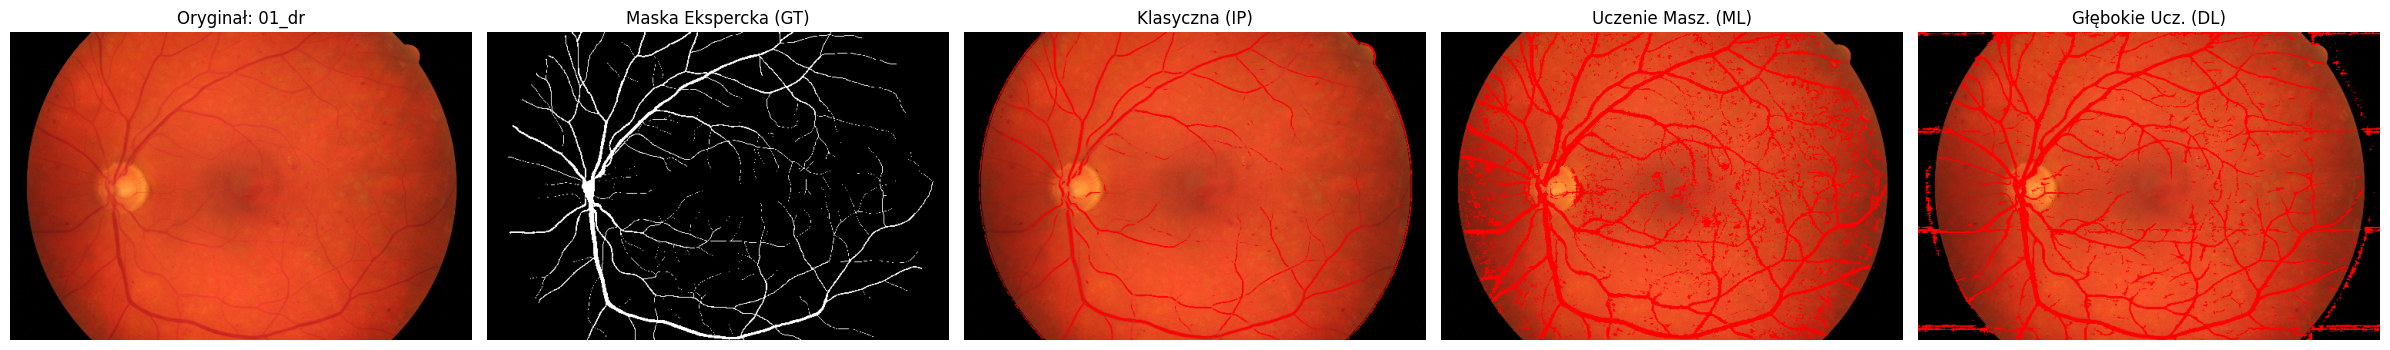

=== ANALIZA STATYSTYCZNA DLA OBRAZU: 01_dr ===
[STATUS] Obraz należał do zbioru treningowego ML i DL.
Miara oceny                    | Przetwarzanie (IP)   | Uczenie Masz. (ML)   | Głębokie Ucz. (DL)  
---------------------------------------------------------------------------------------------------------
Trafność (Accuracy)            | 0.9578               | 0.8787               | 0.9133              
Czułość (Sensitivity)          | 0.4587               | 0.8914               | 0.9088              
Swoistość (Specificity)        | 0.9847               | 0.8780               | 0.9135              
Średnia Geometryczna (G-Mean)  | 0.6721               | 0.8847               | 0.9112              

Macierz pomyłek (Klasyczna IP):
[[224250   3489]
 [  6637   5624]]

Macierz pomyłek (Random Forest ML):
[[199966  27773]
 [  1332  10929]]

Macierz pomyłek (U-Net DL):
[[208048  19691]
 [  1118  11143]]



KeyboardInterrupt: 

In [85]:
for idx in range(len(images)) :
    img = images[idx]
    gt = expert_masks[idx]
    name = image_names[idx]
    
    # Generowanie masek z 3 metod
    mask_ip = pipeline_image_processing(img)
    mask_ml = predict_ml_full_image(img, ml_classifier)
    mask_dl = predict_dl_full_image(img, unet_model)
    
    # Obliczanie metryk
    metrics_ip = calculate_metrics(gt, mask_ip)
    metrics_ml = calculate_metrics(gt, mask_ml)
    metrics_dl = calculate_metrics(gt, mask_dl)
    
    # Przygotowanie wizualizacji (kolor czerwony)
    vis_ip = img.copy(); vis_ip[mask_ip == 1] = [0, 0, 255]
    vis_ml = img.copy(); vis_ml[mask_ml == 1] = [0, 0, 255]
    vis_dl = img.copy(); vis_dl[mask_dl == 1] = [0, 0, 255]
    
    fig, axes = plt.subplots(1, 5, figsize=(24, 5))
    axes[0].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    axes[0].set_title(f"Oryginał: {name}")
    axes[0].axis('off')
    
    axes[1].imshow(gt, cmap='gray')
    axes[1].set_title("Maska Ekspercka (GT)")
    axes[1].axis('off')
    
    axes[2].imshow(cv2.cvtColor(vis_ip, cv2.COLOR_BGR2RGB))
    axes[2].set_title("Klasyczna (IP)")
    axes[2].axis('off')
    
    axes[3].imshow(cv2.cvtColor(vis_ml, cv2.COLOR_BGR2RGB))
    axes[3].set_title("Uczenie Masz. (ML)")
    axes[3].axis('off')
    
    axes[4].imshow(cv2.cvtColor(vis_dl, cv2.COLOR_BGR2RGB))
    axes[4].set_title("Głębokie Ucz. (DL)")
    axes[4].axis('off')
    
    plt.tight_layout()
    plt.show()
    
    print(f"=== ANALIZA STATYSTYCZNA DLA OBRAZU: {name} ===")
    if idx >= 5:
        print("[STATUS] UWAGA: Obraz stanowi niezależny testowy zbiór HOLD-OUT dla ML oraz DL!")
    else:
        print("[STATUS] Obraz należał do zbioru treningowego ML i DL.")
        
    print(f"{'Miara oceny':<30} | {'Przetwarzanie (IP)':<20} | {'Uczenie Masz. (ML)':<20} | {'Głębokie Ucz. (DL)':<20}")
    print("-" * 105)
    print(f"{'Trafność (Accuracy)':<30} | {metrics_ip['Acc']:<20.4f} | {metrics_ml['Acc']:<20.4f} | {metrics_dl['Acc']:<20.4f}")
    print(f"{'Czułość (Sensitivity)':<30} | {metrics_ip['Sens']:<20.4f} | {metrics_ml['Sens']:<20.4f} | {metrics_dl['Sens']:<20.4f}")
    print(f"{'Swoistość (Specificity)':<30} | {metrics_ip['Spec']:<20.4f} | {metrics_ml['Spec']:<20.4f} | {metrics_dl['Spec']:<20.4f}")
    print(f"{'Średnia Geometryczna (G-Mean)':<30} | {metrics_ip['G-Mean']:<20.4f} | {metrics_ml['G-Mean']:<20.4f} | {metrics_dl['G-Mean']:<20.4f}")
    
    print(f"\nMacierz pomyłek (Klasyczna IP):\n{metrics_ip['CM']}\n")
    print(f"Macierz pomyłek (Random Forest ML):\n{metrics_ml['CM']}\n")
    print(f"Macierz pomyłek (U-Net DL):\n{metrics_dl['CM']}")
    print("=" * 105 + "\n")